# Faz 1 — Keşif & EDA (Exploratory Data Analysis)

Bu defter, tahmin modeline girmeden önce veriyi tanımak için hazırlanmıştır.
Amaç: veri kalitesini doğrulamak, talebin zaman içindeki desenini görmek ve
Faz 2'deki model için hangi özelliklerin (feature) gerekli olduğuna karar vermek.

**Çalıştırma:** Hücreleri yukarıdan aşağıya sırayla çalıştır (Shift+Enter).

## 1. Kurulum ve veri yükleme

In [1]:
import sys
from pathlib import Path

# 'src' klasorunu modul yoluna ekle (notebook 'notebooks/' icinde calisir)
SRC = Path.cwd() / "src"
if not SRC.exists():
    SRC = Path.cwd().parent / "src"
sys.path.append(str(SRC))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_loader import load_data, check_coverage
from utils import get_coordinates

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (11, 4)

data = load_data()
print("Veri yuklendi.")

Veri yuklendi.


In [2]:
# 4 veri setinin boyutlari
for ad, df in data.items():
    print(f"{ad:10s} {str(df.shape):14s} sutunlar={list(df.columns)}")

desi       (10770, 4)     sutunlar=['origin', 'destination', 'date', 'desi']
koordinat  (17, 3)        sutunlar=['center', 'lat', 'lon']
kiralik    (12, 4)        sutunlar=['origin', 'destination', 'vehicle_count', 'vehicle_type']
arac       (4, 6)         sutunlar=['vehicle_type', 'capacity', 'rental_daily_cost', 'rental_km_cost', 'spot_daily_cost', 'spot_km_cost']


## 2. Desi_talep — genel yapı

Tahmin edeceğimiz ana veri. Her satır: bir günde bir (çıkış → varış)
güzergahında taşınan toplam desi.

In [3]:
desi = data["desi"]
display(desi.head())
print("\nEksik deger sayisi:")
print(desi.isnull().sum())
print("\nDesi istatistikleri:")
display(desi["desi"].describe())

,origin,destination,date,desi
0,Mersin,Eskişehir,2026-01-01,379.50
1,Kocaeli,Şanlıurfa,2026-01-01,1239.48
2,Kocaeli,Tekirdağ,2026-01-01,2852.70
3,Sivas,Eskişehir,2026-01-01,638.60
4,Kocaeli,Sivas,2026-01-01,1001.60



Eksik deger sayisi:
origin         0
destination    0
date           0
desi           0
dtype: int64

Desi istatistikleri:


count    10770.000000
mean     11603.350648
std       9768.833758
min          5.180000
25%       4669.500000
50%       9449.300000
75%      16153.740000
max      67808.200000
Name: desi, dtype: float64

## 3. Tarih aralığı ve süreklilik

Veride atlanan gün var mı?

In [4]:
print("Ilk tarih :", desi["date"].min().date())
print("Son tarih :", desi["date"].max().date())
print("Gun sayisi:", desi["date"].nunique())

tam_aralik = pd.date_range(desi["date"].min(), desi["date"].max())
eksik = sorted(set(tam_aralik) - set(desi["date"].unique()))
print("Eksik gun :", [d.date() for d in eksik] if eksik else "YOK - kesintisiz")

Ilk tarih : 2026-01-01
Son tarih : 2026-05-10
Gun sayisi: 130
Eksik gun : YOK - kesintisiz


## 4. Günlük satır sayısı — panel dengesizliği

Her gün kaç farklı güzergahta teslimat olmuş? Bu sayı sabit değilse
panel dengesiz demektir: bazı rotalar her gün aktif değil.

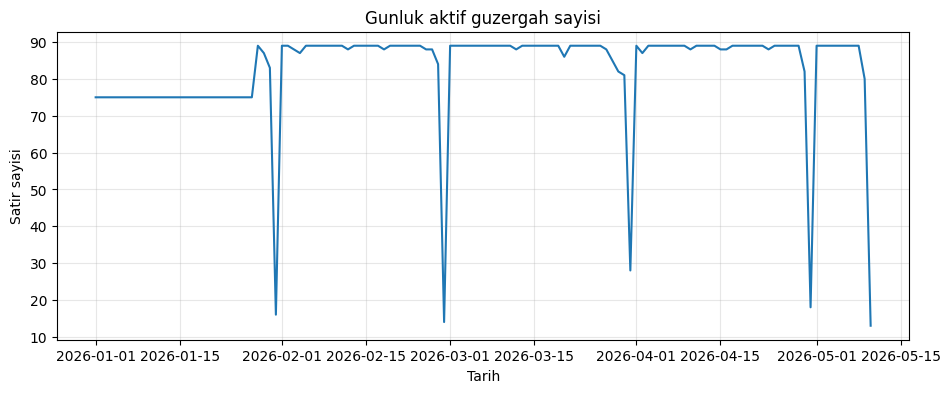

En az: 13 | En cok: 89

Son 5 gun:
date
2026-05-06    89
2026-05-07    89
2026-05-08    89
2026-05-09    80
2026-05-10    13
dtype: int64


In [5]:
gunluk_satir = desi.groupby("date").size()

plt.plot(gunluk_satir.index, gunluk_satir.values)
plt.title("Gunluk aktif guzergah sayisi")
plt.xlabel("Tarih"); plt.ylabel("Satir sayisi")
plt.grid(alpha=0.3)
plt.show()

print("En az:", gunluk_satir.min(), "| En cok:", gunluk_satir.max())
print("\nSon 5 gun:")
print(gunluk_satir.tail())

**Gözlem:** Günlük güzergah sayısı zamanla artıyor (yeni rotalar
devreye giriyor) ve son gün (10 Mayıs) belirgin biçimde düşük —
muhtemelen veri çekimi yarıda kesilmiş eksik bir gün. Modeli eğitirken
bu günü dışlamak gerekebilir.

## 5. Zaman içinde toplam desi

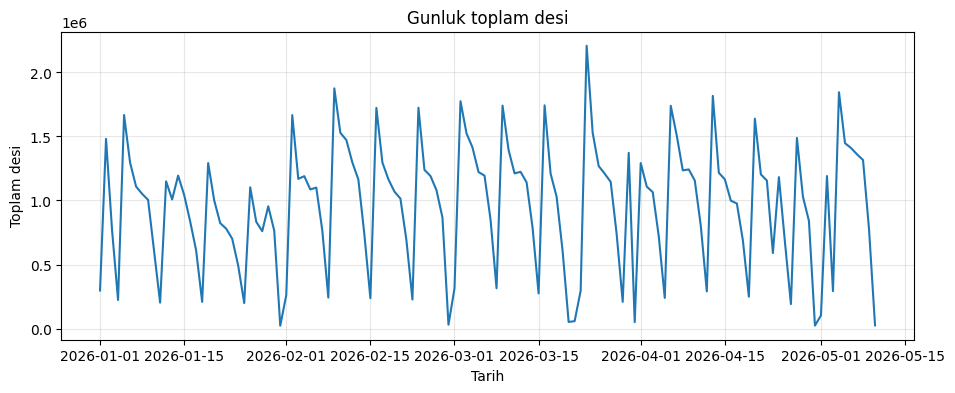

In [6]:
gunluk_desi = desi.groupby("date")["desi"].sum()

plt.plot(gunluk_desi.index, gunluk_desi.values)
plt.title("Gunluk toplam desi")
plt.xlabel("Tarih"); plt.ylabel("Toplam desi")
plt.grid(alpha=0.3)
plt.show()

## 6. Haftalık desen (haftanın günü etkisi)

Talep haftanın gününe göre değişiyor mu? Değişiyorsa modele
"haftanın günü" özelliğini eklememiz gerekir.

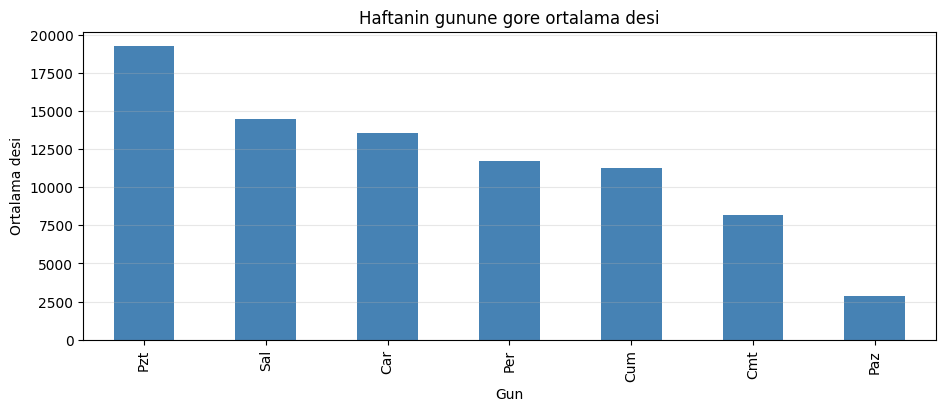

In [7]:
gun_isim = {0: "Pzt", 1: "Sal", 2: "Car", 3: "Per", 4: "Cum", 5: "Cmt", 6: "Paz"}
desi_gun = desi.copy()
desi_gun["hafta_gunu"] = desi_gun["date"].dt.dayofweek

ortalama = desi_gun.groupby("hafta_gunu")["desi"].mean()
ortalama.index = [gun_isim[g] for g in ortalama.index]

ortalama.plot(kind="bar", color="steelblue")
plt.title("Haftanin gunune gore ortalama desi")
plt.xlabel("Gun"); plt.ylabel("Ortalama desi")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 7. Desi değerlerinin dağılımı

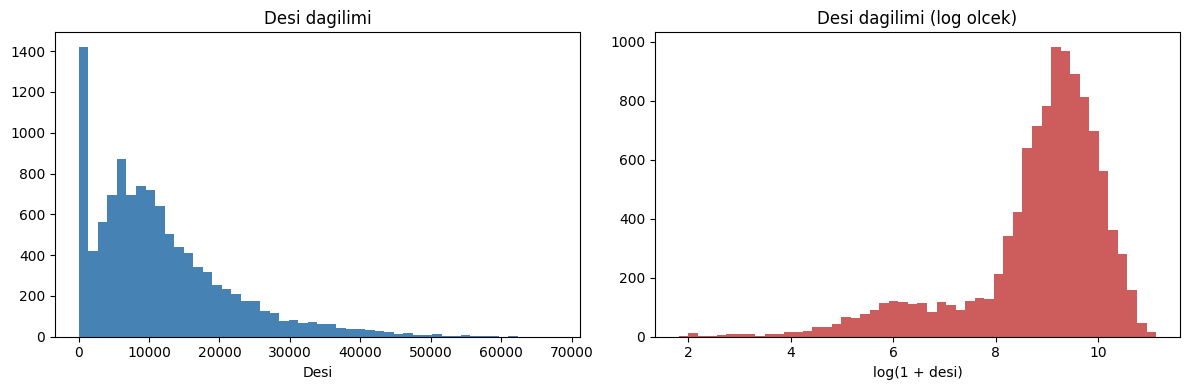

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(desi["desi"], bins=50, color="steelblue")
axes[0].set_title("Desi dagilimi"); axes[0].set_xlabel("Desi")

axes[1].hist(np.log1p(desi["desi"]), bins=50, color="indianred")
axes[1].set_title("Desi dagilimi (log olcek)"); axes[1].set_xlabel("log(1 + desi)")

plt.tight_layout()
plt.show()

**Gözlem:** Dağılım sağa çarpık — çoğu güzergah küçük hacimli,
az sayıda güzergah çok büyük. Log dönüşümü dağılımı simetrikleştiriyor;
model eğitiminde log hedef kullanmak değerlendirilebilir.

## 8. Güzergah analizi

In [9]:
desi_r = desi.copy()
desi_r["route"] = desi_r["origin"] + " -> " + desi_r["destination"]

print("Toplam farkli guzergah:", desi_r["route"].nunique())

print("\nEn yuksek hacimli 10 guzergah (toplam desi):")
display(desi_r.groupby("route")["desi"].sum().sort_values(ascending=False).head(10))

aktif_gun = desi_r.groupby("route")["date"].nunique()
print("Guzergah basina aktif gun -> en az:", aktif_gun.min(),
      "| en cok:", aktif_gun.max(), "| toplam gun:", desi["date"].nunique())

Toplam farkli guzergah: 89

En yuksek hacimli 10 guzergah (toplam desi):


route
İstanbul -> Eskişehir    3675555.30
İstanbul -> Balıkesir    3382732.20
İstanbul -> Manisa       3352841.52
İstanbul -> Tekirdağ     3080969.28
İstanbul -> Yalova       3053646.26
Kocaeli -> İstanbul      3017892.12
Kocaeli -> Tekirdağ      3009254.40
Kocaeli -> Yalova        2975661.10
Kocaeli -> Balıkesir     2871992.96
Kocaeli -> Eskişehir     2612656.80
Name: desi, dtype: float64

Guzergah basina aktif gun -> en az: 98 | en cok: 130 | toplam gun: 130


**Gözlem:** Bazı güzergahlar 130 günün tamamında aktifken bazıları
çok daha az gün aktif — panel dengesiz. Her gün × her
güzergah için tam bir tablo kurup teslimat olmayan gün-güzergah
hücrelerini **0 desi** ile dolduracağız.

## 9. Koordinat kapsama kontrolü

In [10]:
# Desi/Kiralik merkezleri Koordinatlar'da var mi?
check_coverage(data)

# utils.get_coordinates eksik koordinatlari tamamliyor
coords = get_coordinates(data)
print("\nKoordinat tablosu (tamamlanmis):", coords.shape[0], "merkez")

UYARI - Desi'de olup Koordinatlar'da OLMAYAN: ['Kocaeli']
UYARI - Kiralik'ta olup Koordinatlar'da OLMAYAN: ['Kocaeli']
Koordinata elle eklendi: ['Kocaeli']

Koordinat tablosu (tamamlanmis): 18 merkez


## 10. Özet — Bulgular ve modele etkisi

| Bulgu | Modele etkisi |
|---|---|
| 130 gün kesintisiz veri (1 Oca - 10 May 2026) | 11-17 Mayıs (7 gün) tahmin edilecek |
| 10 Mayıs eksik gün (yalnızca 13 satır) | Eğitimden çıkarılacak / kısmi kabul edilecek |
| Panel dengesiz (~75 -> ~89 aktif güzergah) | Eksik gün-güzergahlar 0 ile doldurulacak |
| Belirgin haftalık desen | "Haftanın günü" özelliği eklenecek |
| Desi sağa çarpık dağılım | Log dönüşümlü hedef değerlendirilecek |
| Kocaeli koordinatı eksikti | utils.py'de elle eklendi (çözüldü) |

**Sonraki adım :** panel'i dengeleme + özellik üretimi (lag, hareketli
ortalama, takvim) + LightGBM modeli + time-based holdout ile doğrulama.

## 11. Analiz ve Veri Değerlendirme Raporu (EDA & SPO Değerlendirmesi)

Bu keşifsel veri analizi (EDA) sürecinde elde edilen bulgular, HepsiJET'in anahat lojistik ağının veri karakteristiğini ortaya koyarken; ön tasarım raporumuzda kurgulanan **Smart Predict-then-Optimize (SPO)** ve iki aşamalı stokastik optimizasyon süreçlerimizi doğrudan şekillendirecek kritik sinyaller barındırmaktadır:

---

### 1. Rota Dinamikleri ve Hacim Dağılımı (Varyans ve Çarpıklık Yönetimi)

* **Analitik Tespit:** Desi dağılım grafiklerinde görüldüğü üzere, talep dağılımı **aşırı sağa çarpıktır (highly right-skewed)**. Güzergahların çok büyük bir bölümü düşük hacimli kılcal hatlardan (spoke) oluşurken, sınırlı sayıda ana hat (hub-to-hub) tüm hacmin omurgasını taşımaktadır (Pareto İlkesi).
* **SPO ve Karar İzdüşümü:** Bu yüksek çarpıklık, makine öğrenmesi modelinin (LightGBM) büyük rotalardaki kayıpları minimize etmek adına küçük rotalardaki dinamikleri göz ardı etmesine (bias) yol açabilir. Hedef değişkene uygulanacak **$log1p(desi)$** dönüşümü, varyansı stabilize ederek LightGBM modelinin tüm hatlarda dengeli öğrenmesini sağlayacaktır. Optimizasyon katmanında ise bu durum, spot araç ihtiyacının ($y_{ij}$) sadece belirli "peak" koridorlarda yoğunlaşacağını; dolayısıyla gelişmiş aşamadaki konsolidasyon ($w_j$) kararlarının bu ana hatlarda konumlandırılması gerektiğini gösterir.

---

### 2. Haftalık Periyodik Ritmler ve Sezonluk Etki (Filo Yönetimi Asimetrisi)

* **Analitik Tespit:** "Haftanın gününe göre ortalama desi" grafiği, e-ticaret lojistiğinin klasik **güçlü haftalık sezonluğunu (weekly seasonality)** net bir şekilde doğrulamaktadır. Pazartesi ve Salı günleri, hafta sonu siparişlerinin transfer merkezlerine yığılmasıyla zirve (peak) noktalara ulaşırken; Pazar günleri talep dip yapmaktadır.
* **SPO ve Karar İzdüşümü:** Tahmin modelinin bu periyodik ritmi yakalayabilmesi için `dayofweek` ve `is_weekend` takvim özelliklerinin eklenmesi zorunludur. Optimizasyon tarafında ise bu durum, sabit kiralık araç kapasitesi ile dalgalı talep arasındaki asimetriyi gösterir. Sabit kiralık araç atamaları ($x_{ij}^k$) batık maliyet (sunk cost) yönetimiyle doldurulmalı; zirve günlerde kiralık kapasitenin yetersiz kaldığı durumlar ise iki aşamalı stokastik modelde spot araç sayısı ($y_{ij}$) ve SLA gecikme ($S_j$) değişkenleri dengelenerek yönetilmelidir.

---

### 3. Panel Dengesizliği ve Ağ Genişlemesi (Gereksiz Spot Maliyeti Blokajı)

* **Analitik Tespit:** Aktif güzergah sayısının zamanla artması (~75'ten ~89'a) ve bazı rotaların 130 günün yalnızca belirli dönemlerinde aktif olması, veri setinin dengesiz bir panel veri (unbalanced panel) yapısına sahip olduğunu kanıtlamaktadır.
* **SPO ve Karar İzdüşümü:** Lojistik operasyonlarda bir güzergahta kaydın bulunmaması veri kaybı değil, o gün o rotada talep olmaması (0 desi) anlamına gelir. Bu nedenle veri mühendisliği aşamasında, veri tabanında yer almayan `gün x rota` eşleşmeleri 0 desi ile doldurulmalıdır (Zero-filling). Aksi takdirde tahmin modeli durağan günlerde aşırı tahmin (over-forecasting) üretecek ve optimizasyon motorunun gereksiz yere yüksek maliyetli spot araç ($y_{ij}$) kiralama kararı vermesine yol açacaktır.